# Model Rekomendasi Pemesanan Stok — Naive Bayes (Final)

Notebook ini sudah disesuaikan dengan struktur project Google Drive:

```text
project_naive_bayes/
├── data/
│   ├── raw/dataset_toko_barokah.csv
│   └── processed/dataset_toko_barokah_modeling.csv
├── model/
├── notebook/
└── output/
```

Output utama: klasifikasi **Perlu Pesan/Tidak**, probabilitas, jumlah pemesanan, metrik evaluasi, model `.pkl`, prediksi test, dan rekomendasi seluruh barang.

Perbaikan: memakai target modeling terbaru, temporal split bawaan dataset, fitur tanpa leakage, PowerTransformer, expanding-window cross-validation, threshold validation, evaluasi test terpisah, dan rekomendasi kondisi terkini dari dataset raw.

In [12]:
from pathlib import Path
from datetime import datetime
import json, math, warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    classification_report, ConfusionMatrixDisplay, f1_score,
    mean_absolute_error, precision_score, PrecisionRecallDisplay,
    recall_score, roc_auc_score,
)
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

## 1. Konfigurasi project dan lokasi file

In [13]:
IN_COLAB=False
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB=True
except ImportError:
    print('Berjalan di luar Google Colab.')

PROJECT_ROOT=(Path('/content/drive/MyDrive/project_naive_bayes') if IN_COLAB else Path.cwd())

def first_existing(paths, required=True):
    for p in paths:
        if p.exists(): return p
    if required:
        raise FileNotFoundError('File tidak ditemukan. Lokasi diperiksa:\n'+'\n'.join(f'- {p}' for p in paths))
    return None

MODELING_DATA_PATH=first_existing([
    PROJECT_ROOT/'data'/'processed'/'dataset_toko_barokah_modeling.csv',
    PROJECT_ROOT/'data'/'dataset_toko_barokah_modeling.csv',
    PROJECT_ROOT/'dataset_toko_barokah_modeling.csv',
    Path('/mnt/data/dataset_toko_barokah_modeling.csv'),
])
RAW_DATA_PATH=first_existing([
    PROJECT_ROOT/'data'/'raw'/'dataset_toko_barokah.csv',
    PROJECT_ROOT/'data'/'dataset_toko_barokah.csv',
    PROJECT_ROOT/'dataset_toko_barokah.csv',
    Path('/mnt/data/dataset_toko_barokah.csv'),
], required=False)

MODEL_DIR=PROJECT_ROOT/'model'; OUTPUT_DIR=PROJECT_ROOT/'output'; NOTEBOOK_DIR=PROJECT_ROOT/'notebook'
for folder in [MODEL_DIR, OUTPUT_DIR, NOTEBOOK_DIR]: folder.mkdir(parents=True, exist_ok=True)

MIN_RECALL_VALIDATION=0.70
DEFAULT_LEAD_TIME_DAYS=3
DEFAULT_REVIEW_PERIOD_DAYS=7
DEFAULT_SERVICE_LEVEL=0.95
PREDICTION_HORIZON_DAYS=1
DEFAULT_ON_ORDER=0

print('PROJECT_ROOT :', PROJECT_ROOT)
print('MODELING DATA:', MODELING_DATA_PATH)
print('RAW DATA     :', RAW_DATA_PATH)
print('MODEL DIR    :', MODEL_DIR)
print('OUTPUT DIR   :', OUTPUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_ROOT : /content/drive/MyDrive/project_naive_bayes
MODELING DATA: /content/drive/MyDrive/project_naive_bayes/data/processed/dataset_toko_barokah_modeling.csv
RAW DATA     : /content/drive/MyDrive/project_naive_bayes/data/raw/dataset_toko_barokah.csv
MODEL DIR    : /content/drive/MyDrive/project_naive_bayes/model
OUTPUT DIR   : /content/drive/MyDrive/project_naive_bayes/output


## 2. Membaca dataset modeling, memvalidasi kolom, dan menentukan target

In [14]:
df=pd.read_csv(MODELING_DATA_PATH)
required={
    'tanggal','tanggal_target','nama_barang','stok_akhir','barang_keluar',
    'rata_penjualan_7','std_penjualan_7','rata_penjualan_30',
    'std_penjualan_30','cakupan_stok_hari','hari_dalam_minggu',
    'horizon_hari_target','inventory_position','target_stock',
    'target_perlu_pesan_berikutnya','target_jumlah_pesan_berikutnya','split_data'
}
missing=required-set(df.columns)
if missing: raise ValueError(f'Kolom dataset modeling belum lengkap: {sorted(missing)}')

df['tanggal']=pd.to_datetime(df['tanggal'], errors='coerce')
df['tanggal_target']=pd.to_datetime(df['tanggal_target'], errors='coerce')
df['target']=df['target_perlu_pesan_berikutnya'].map({'Tidak':0,'Perlu Pesan':1})
df=(df.drop_duplicates().dropna(subset=['tanggal','tanggal_target','nama_barang','target','split_data'])
      .sort_values(['tanggal_target','nama_barang']).reset_index(drop=True))
df['target']=df['target'].astype(int)

print('Ukuran data:', df.shape)
print('Jumlah barang:', df.nama_barang.nunique())
print('Periode target:', df.tanggal_target.min().date(), 's.d.', df.tanggal_target.max().date())
display(df.head())

Ukuran data: (26883, 34)
Jumlah barang: 78
Periode target: 2024-08-09 s.d. 2025-08-31


,tanggal,nama_barang,kategori,stok_awal,barang_masuk,barang_keluar,stok_akhir,label_transaksi_asli,bulan,hari_dalam_minggu,minggu_dalam_tahun,penjualan_lag_1,penjualan_lag_7,rata_penjualan_7,std_penjualan_7,rata_penjualan_30,std_penjualan_30,cakupan_stok_hari,lead_time_hari,review_period_hari,service_level,barang_dalam_pemesanan_asumsi,inventory_position,safety_stock,reorder_point,target_stock,label_perlu_pesan_saat_ini,jumlah_pesan_saat_ini,tanggal_target,horizon_hari_target,target_perlu_pesan_berikutnya,target_jumlah_pesan_berikutnya,split_data,target
0,2024-08-08,Aqua 600ml,Minuman,41.0000,0.0000,1.0000,40.0000,Tidak,8,3,32,2.0000,3.0000,2.2857,1.0302,2.2857,1.0302,17.5000,3,7,0.9500,0,40.0000,3,10,26,Tidak,0,2024-08-09,1,Tidak,0,Train,0
1,2024-08-08,Baygon Spray,Pembasmi Serangga,24.0000,0.0000,5.0000,19.0000,Tidak,8,3,32,3.0000,0.0000,3.0000,2.5071,3.0000,2.5071,6.3333,3,7,0.9500,0,19.0000,8,17,38,Tidak,0,2024-08-09,1,Perlu Pesan,25,Train,1
2,2024-08-08,Bear Brand,Susu,29.0000,0.0000,3.0000,26.0000,Tidak,8,3,32,2.0000,1.0000,2.0000,0.7559,2.0000,0.7559,13.0000,3,7,0.9500,0,26.0000,3,9,23,Tidak,0,2024-08-09,1,Tidak,0,Train,0
3,2024-08-08,Beras IR64 5kg,Beras,42.0000,0.0000,3.0000,39.0000,Tidak,8,3,32,5.0000,3.0000,3.5714,1.4983,3.5714,1.4983,10.9200,3,7,0.9500,0,39.0000,5,15,40,Tidak,0,2024-08-09,1,Tidak,0,Train,0
4,2024-08-08,Beras Ramos 5kg,Beras,63.0000,0.0000,1.0000,62.0000,Tidak,8,3,32,3.0000,4.0000,2.1429,1.1249,2.1429,1.1249,28.9333,3,7,0.9500,0,62.0000,4,10,25,Tidak,0,2024-08-09,1,Tidak,0,Train,0


## 3. Fitur aman dari leakage dan temporal split

GaussianNB hanya memakai fitur numerik kontinu. Kolom label lama, label saat ini, safety stock, reorder point, target stock, target klasifikasi, target jumlah, dan split tidak dipakai sebagai fitur.

In [15]:
FEATURES=[
    'stok_akhir','barang_keluar','rata_penjualan_7','std_penjualan_7',
    'rata_penjualan_30','std_penjualan_30','cakupan_stok_hari',
    'hari_dalam_minggu','horizon_hari_target'
]
for c in FEATURES: df[c]=pd.to_numeric(df[c], errors='coerce')

train_df=df[df.split_data=='Train'].copy().reset_index(drop=True)
val_df=df[df.split_data=='Validation'].copy().reset_index(drop=True)
test_df=df[df.split_data=='Test'].copy().reset_index(drop=True)
for name,part in [('Train',train_df),('Validation',val_df),('Test',test_df)]:
    if part.empty or part.target.nunique()<2: raise ValueError(f'Split {name} tidak valid.')
    print(f'{name:10s}: {len(part):6,d} | Perlu Pesan={part.target.mean():.2%} | {part.tanggal_target.min().date()} s.d. {part.tanggal_target.max().date()}')

X_train,y_train=train_df[FEATURES],train_df.target
X_val,y_val=val_df[FEATURES],val_df.target
X_test,y_test=test_df[FEATURES],test_df.target

distribution=df.target.map({0:'Tidak',1:'Perlu Pesan'}).value_counts().rename_axis('kelas').to_frame('jumlah')
distribution['persentase']=distribution.jumlah/len(df)
display(distribution)

Train     : 18,817 | Perlu Pesan=4.44% | 2024-08-09 s.d. 2025-05-06
Validation:  3,932 | Perlu Pesan=4.02% | 2025-05-07 s.d. 2025-07-03
Test      :  4,134 | Perlu Pesan=4.31% | 2025-07-04 s.d. 2025-08-31


,jumlah,persentase
kelas,,
Tidak,25711,0.9564
Perlu Pesan,1172,0.0436


## 4. Baseline, pipeline, dan expanding-window cross-validation

In [5]:
baseline=DummyClassifier(strategy='most_frequent').fit(X_train,y_train)
baseline_pred=baseline.predict(X_test)
baseline_metrics={
    'accuracy':accuracy_score(y_test,baseline_pred),
    'balanced_accuracy':balanced_accuracy_score(y_test,baseline_pred),
    'precision_perlu_pesan':precision_score(y_test,baseline_pred,zero_division=0),
    'recall_perlu_pesan':recall_score(y_test,baseline_pred,zero_division=0),
    'f1_perlu_pesan':f1_score(y_test,baseline_pred,zero_division=0),
}

def expanding_date_splits(dates,target,n_splits=5):
    dates=pd.Series(pd.to_datetime(dates)).reset_index(drop=True)
    target=pd.Series(target).reset_index(drop=True)
    unique=np.array(sorted(dates.unique()))
    boundaries=np.linspace(0,len(unique),min(n_splits,max(2,len(unique)-2))+2,dtype=int)
    splits=[]
    for fold in range(1,len(boundaries)-1):
        tr_dates=unique[:boundaries[fold]]; va_dates=unique[boundaries[fold]:boundaries[fold+1]]
        tr=np.flatnonzero(dates.isin(tr_dates).to_numpy()); va=np.flatnonzero(dates.isin(va_dates).to_numpy())
        if len(tr) and len(va) and target.iloc[tr].nunique()==2 and target.iloc[va].nunique()==2:
            splits.append((tr,va))
    if len(splits)<2: raise ValueError('Fold temporal valid kurang dari dua.')
    return splits

pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('power',PowerTransformer(method='yeo-johnson',standardize=True)),
    ('model',GaussianNB()),
])
cv_splits=expanding_date_splits(train_df.tanggal_target,y_train,5)
grid=GridSearchCV(
    pipeline,
    {'model__var_smoothing':np.logspace(-12,-3,10)},
    scoring={'average_precision':'average_precision','f1':'f1','balanced_accuracy':'balanced_accuracy'},
    refit='average_precision',cv=cv_splits,n_jobs=1,return_train_score=False
)
grid.fit(X_train,y_train)
cv_results=(pd.DataFrame(grid.cv_results_)[[
    'param_model__var_smoothing','mean_test_average_precision','mean_test_f1','mean_test_balanced_accuracy'
]].sort_values('mean_test_average_precision',ascending=False).reset_index(drop=True))
print('Parameter terbaik:',grid.best_params_)
print('CV PR-AUC terbaik:',round(grid.best_score_,4))
display(cv_results)

Parameter terbaik: {'model__var_smoothing': np.float64(0.001)}
CV PR-AUC terbaik: 0.5444


,param_model__var_smoothing,mean_test_average_precision,mean_test_f1,mean_test_balanced_accuracy
0,0.0010,0.5444,0.5501,0.9341
1,0.0000,0.5443,0.5517,0.9344
2,0.0000,0.5443,0.5517,0.9344
3,0.0000,0.5443,0.5517,0.9344
4,0.0000,0.5443,0.5517,0.9344
5,0.0000,0.5443,0.5517,0.9344
6,0.0000,0.5443,0.5517,0.9344
7,0.0000,0.5443,0.5517,0.9344
8,0.0000,0.5442,0.5517,0.9344
9,0.0001,0.5441,0.5515,0.9343


## 5. Memilih threshold pada Validation set

In [6]:
val_probability=grid.best_estimator_.predict_proba(X_val)[:,1]
rows=[]
for threshold in np.arange(0.01,1.00,0.01):
    pred=(val_probability>=threshold).astype(int)
    rows.append({
        'threshold':round(float(threshold),2),
        'accuracy':accuracy_score(y_val,pred),
        'balanced_accuracy':balanced_accuracy_score(y_val,pred),
        'precision':precision_score(y_val,pred,zero_division=0),
        'recall':recall_score(y_val,pred,zero_division=0),
        'f1':f1_score(y_val,pred,zero_division=0),
    })
threshold_results=pd.DataFrame(rows)
eligible=threshold_results[threshold_results.recall>=MIN_RECALL_VALIDATION]
best_row=(eligible if not eligible.empty else threshold_results).sort_values(
    ['f1','precision','balanced_accuracy'],ascending=False).iloc[0]
BEST_THRESHOLD=float(best_row.threshold)
print('Threshold terbaik:',BEST_THRESHOLD)
display(best_row.to_frame('nilai'))

Threshold terbaik: 0.99


,nilai
threshold,0.9900
accuracy,0.9631
balanced_accuracy,0.8413
precision,0.5308
recall,0.7089
f1,0.6070


## 6. Training final dan evaluasi Test set

In [7]:
train_val=pd.concat([train_df,val_df],ignore_index=True).sort_values(['tanggal_target','nama_barang'])
final_model=clone(grid.best_estimator_).fit(train_val[FEATURES],train_val.target)
test_probability=final_model.predict_proba(X_test)[:,1]
test_prediction=(test_probability>=BEST_THRESHOLD).astype(int)

projected_inventory=np.maximum(0,test_df.inventory_position.to_numpy()-test_df.rata_penjualan_30.to_numpy()*test_df.horizon_hari_target.to_numpy())
test_qty=np.where(test_prediction==1,np.maximum(0,np.ceil(test_df.target_stock.to_numpy()-projected_inventory)),0).astype(int)
actual_qty=test_df.target_jumlah_pesan_berikutnya.to_numpy()
pos_mask=y_test.to_numpy()==1

metrics={
    'accuracy':accuracy_score(y_test,test_prediction),
    'balanced_accuracy':balanced_accuracy_score(y_test,test_prediction),
    'precision_perlu_pesan':precision_score(y_test,test_prediction,zero_division=0),
    'recall_perlu_pesan':recall_score(y_test,test_prediction,zero_division=0),
    'f1_perlu_pesan':f1_score(y_test,test_prediction,zero_division=0),
    'pr_auc':average_precision_score(y_test,test_probability),
    'roc_auc':roc_auc_score(y_test,test_probability),
    'mae_jumlah_pesan_semua_data':mean_absolute_error(actual_qty,test_qty),
    'mae_jumlah_pesan_target_positif':mean_absolute_error(actual_qty[pos_mask],test_qty[pos_mask]) if pos_mask.any() else np.nan,
    'threshold':BEST_THRESHOLD,
    'best_var_smoothing':float(grid.best_params_['model__var_smoothing']),
}
comparison=pd.DataFrame([
    {'model':'Baseline kelas mayoritas',**baseline_metrics},
    {'model':'Gaussian Naive Bayes final',
     'accuracy':metrics['accuracy'],'balanced_accuracy':metrics['balanced_accuracy'],
     'precision_perlu_pesan':metrics['precision_perlu_pesan'],
     'recall_perlu_pesan':metrics['recall_perlu_pesan'],'f1_perlu_pesan':metrics['f1_perlu_pesan']}
]).set_index('model')
display(comparison)
print(classification_report(y_test,test_prediction,target_names=['Tidak','Perlu Pesan'],zero_division=0))
display(pd.DataFrame([metrics]).T.rename(columns={0:'nilai'}))

,accuracy,balanced_accuracy,precision_perlu_pesan,recall_perlu_pesan,f1_perlu_pesan
model,,,,,
Baseline kelas mayoritas,0.9569,0.5000,0.0000,0.0000,0.0000
Gaussian Naive Bayes final,0.9659,0.8454,0.5853,0.7135,0.6430


              precision    recall  f1-score   support

       Tidak       0.99      0.98      0.98      3956
 Perlu Pesan       0.59      0.71      0.64       178

    accuracy                           0.97      4134
   macro avg       0.79      0.85      0.81      4134
weighted avg       0.97      0.97      0.97      4134



,nilai
accuracy,0.9659
balanced_accuracy,0.8454
precision_perlu_pesan,0.5853
recall_perlu_pesan,0.7135
f1_perlu_pesan,0.6430
pr_auc,0.6223
roc_auc,0.9807
mae_jumlah_pesan_semua_data,0.8401
mae_jumlah_pesan_target_positif,7.3371
threshold,0.9900


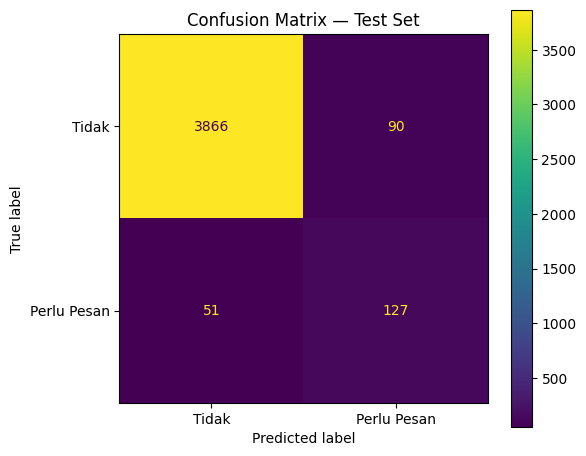

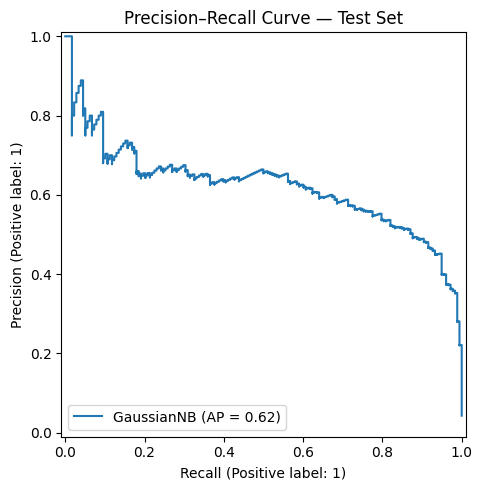

In [8]:
fig,ax=plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(y_test,test_prediction,display_labels=['Tidak','Perlu Pesan'],values_format='d',ax=ax)
ax.set_title('Confusion Matrix — Test Set'); plt.tight_layout()
CONFUSION_PATH=OUTPUT_DIR/'confusion_matrix.png'; fig.savefig(CONFUSION_PATH,dpi=200,bbox_inches='tight'); plt.show()

fig2,ax2=plt.subplots(figsize=(6,5))
PrecisionRecallDisplay.from_predictions(y_test,test_probability,name='GaussianNB',ax=ax2)
ax2.set_title('Precision–Recall Curve — Test Set'); plt.tight_layout()
PR_PATH=OUTPUT_DIR/'precision_recall_curve.png'; fig2.savefig(PR_PATH,dpi=200,bbox_inches='tight'); plt.show()

## 7. Membentuk fitur kondisi terbaru dari dataset raw

In [9]:
def latest_features_from_raw(raw,lead=3,review=7,service=0.95,on_order=0,horizon=1):
    required={'tanggal','nama_barang','kategori','barang_keluar','stok_akhir'}
    missing=required-set(raw.columns)
    if missing: raise ValueError(f'Kolom raw belum lengkap: {sorted(missing)}')
    data=raw.copy(); data['tanggal']=pd.to_datetime(data.tanggal,errors='coerce')
    for c in ['barang_keluar','stok_akhir']: data[c]=pd.to_numeric(data[c],errors='coerce')
    data=data.dropna(subset=['tanggal','nama_barang','barang_keluar','stok_akhir']).sort_values(['nama_barang','tanggal'])
    z=norm.ppf(service); output=[]
    for product,g in data.groupby('nama_barang'):
        g=g.sort_values('tanggal').reset_index(drop=True)
        if len(g)<8: continue
        latest=g.iloc[-1]; history=g.iloc[:-1].barang_keluar.astype(float)
        h7=history.tail(7); h30=history.tail(30)
        avg7=float(h7.mean()); std7=float(h7.std(ddof=0)); avg30=float(h30.mean()); std30=float(h30.std(ddof=0))
        safety=z*std30*math.sqrt(lead); reorder=avg30*lead+safety; target_stock=avg30*(lead+review)+safety
        inventory=float(latest.stok_akhir)+float(on_order)
        output.append({
            'tanggal':latest.tanggal,'nama_barang':product,'kategori':latest.kategori,
            'stok_akhir':float(latest.stok_akhir),'barang_keluar':float(latest.barang_keluar),
            'rata_penjualan_7':avg7,'std_penjualan_7':std7,
            'rata_penjualan_30':avg30,'std_penjualan_30':std30,
            'cakupan_stok_hari':float(latest.stok_akhir)/avg30 if avg30>0 else np.nan,
            'hari_dalam_minggu':int(latest.tanggal.dayofweek),'horizon_hari_target':int(horizon),
            'inventory_position':inventory,'safety_stock':math.ceil(safety),
            'reorder_point':math.ceil(reorder),'target_stock':math.ceil(target_stock),
            'lead_time_hari':lead,'review_period_hari':review,'service_level':service,
            'barang_dalam_pemesanan':float(on_order),
        })
    return pd.DataFrame(output)

if RAW_DATA_PATH is not None:
    latest_features=latest_features_from_raw(pd.read_csv(RAW_DATA_PATH),DEFAULT_LEAD_TIME_DAYS,DEFAULT_REVIEW_PERIOD_DAYS,DEFAULT_SERVICE_LEVEL,DEFAULT_ON_ORDER,PREDICTION_HORIZON_DAYS)
    print('Rekomendasi memakai kondisi terakhir dataset raw.')
else:
    latest_features=df.sort_values(['nama_barang','tanggal']).groupby('nama_barang',as_index=False).tail(1).copy()
    print('PERINGATAN: raw tidak ditemukan; memakai baris terakhir dataset modeling.')
print('Jumlah barang:',len(latest_features)); display(latest_features.head())

Rekomendasi memakai kondisi terakhir dataset raw.
Jumlah barang: 78


,tanggal,nama_barang,kategori,stok_akhir,barang_keluar,rata_penjualan_7,std_penjualan_7,rata_penjualan_30,std_penjualan_30,cakupan_stok_hari,hari_dalam_minggu,horizon_hari_target,inventory_position,safety_stock,reorder_point,target_stock,lead_time_hari,review_period_hari,service_level,barang_dalam_pemesanan
0,2025-08-31,ABC Susu,Kopi,53.0000,3.0000,1.8571,0.8330,2.1000,0.7461,25.2381,6,1,53.0000,3,9,24,3,7,0.9500,0.0000
1,2025-08-31,Aqua 600ml,Minuman,26.0000,5.0000,3.1429,1.2454,2.7333,1.2632,9.5122,6,1,26.0000,4,12,31,3,7,0.9500,0.0000
2,2025-08-31,Baterai ABC AA,Elektronik,15.0000,0.0000,0.1429,0.3499,0.0333,0.1795,450.0000,6,1,15.0000,1,1,1,3,7,0.9500,0.0000
3,2025-08-31,Baterai ABC AAA,Elektronik,11.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,6,1,11.0000,0,0,0,3,7,0.9500,0.0000
4,2025-08-31,Baygon Spray,Pembasmi Serangga,32.0000,7.0000,2.2857,2.4328,2.4667,2.6424,12.9730,6,1,32.0000,8,15,33,3,7,0.9500,0.0000


## 8. Fungsi rekomendasi akhir

### Aturan keputusan hybrid

Rekomendasi akhir menjadi `Perlu Pesan` apabila:

```python
inventory_trigger or (
    model_prediction == 1
    and inventory_quantity > 0
)
```

Dengan demikian, kondisi stok yang sudah mencapai `reorder_point` tetap memicu
pemesanan meskipun probabilitas Naive Bayes belum melewati threshold.


In [10]:
def rekomendasi_pemesanan(nama_barang,stok_saat_ini=None,barang_dalam_pemesanan=None):
    latest=latest_features[latest_features.nama_barang==nama_barang].sort_values('tanggal').tail(1).copy()
    if latest.empty: raise ValueError(f'Barang {nama_barang!r} tidak ditemukan.')
    on_order=float(latest.iloc[0].get('barang_dalam_pemesanan',0) if barang_dalam_pemesanan is None else barang_dalam_pemesanan)
    if stok_saat_ini is not None:
        stok=float(stok_saat_ini); avg=float(latest.iloc[0].rata_penjualan_30)
        latest.loc[:,'stok_akhir']=stok; latest.loc[:,'inventory_position']=stok+on_order
        latest.loc[:,'cakupan_stok_hari']=stok/avg if avg>0 else np.nan
    else: stok=float(latest.iloc[0].stok_akhir)
    prob=float(final_model.predict_proba(latest[FEATURES])[:,1][0]); model_pred=int(prob>=BEST_THRESHOLD)
    avg=float(latest.iloc[0].rata_penjualan_30); horizon=max(1,int(latest.iloc[0].horizon_hari_target))
    projected=max(0,float(latest.iloc[0].inventory_position)-avg*horizon)
    reorder_point=float(latest.iloc[0].reorder_point)
    target_stock=float(latest.iloc[0].target_stock)

    # Aturan hybrid:
    # 1. Pemesanan wajib dilakukan jika projected inventory sudah
    #    mencapai atau berada di bawah reorder point.
    # 2. Model Naive Bayes tetap dapat memberi peringatan lebih awal.
    inventory_trigger=projected<=reorder_point
    inventory_qty=max(0,math.ceil(target_stock-projected))
    final_need=inventory_trigger or (model_pred==1 and inventory_qty>0)
    qty=inventory_qty if final_need else 0

    return pd.DataFrame([{
        'nama_barang':nama_barang,'tanggal_data_terakhir':pd.Timestamp(latest.iloc[0].tanggal).date(),
        'stok_saat_ini':stok,'barang_dalam_pemesanan':on_order,'projected_inventory':round(projected,2),
        'rata_penjualan_harian':round(avg,4),'safety_stock':int(latest.iloc[0].safety_stock),
        'reorder_point':int(latest.iloc[0].reorder_point),'target_stock':int(latest.iloc[0].target_stock),
        'klasifikasi_model':'Perlu Pesan' if model_pred else 'Tidak',
        'probabilitas_perlu_pesan':round(prob,6),'threshold_model':BEST_THRESHOLD,
        'trigger_inventory':'Ya' if inventory_trigger else 'Tidak',
        'rekomendasi_final':'Perlu Pesan' if final_need else 'Tidak',
        'jumlah_stok_harus_dipesan':qty if final_need else 0,
        'accuracy_model_test':metrics['accuracy'],'balanced_accuracy_test':metrics['balanced_accuracy'],
        'precision_perlu_pesan_test':metrics['precision_perlu_pesan'],
        'recall_perlu_pesan_test':metrics['recall_perlu_pesan'],
        'f1_perlu_pesan_test':metrics['f1_perlu_pesan'],'pr_auc_test':metrics['pr_auc'],
    }])

example='Indomie Goreng' if 'Indomie Goreng' in latest_features.nama_barang.values else latest_features.nama_barang.iloc[0]
display(rekomendasi_pemesanan(example).T.rename(columns={0:'hasil'}))

,hasil
nama_barang,Indomie Goreng
tanggal_data_terakhir,2025-08-31
stok_saat_ini,89.0000
barang_dalam_pemesanan,0.0000
projected_inventory,86.1000
rata_penjualan_harian,2.9000
safety_stock,5
reorder_point,14
target_stock,34
klasifikasi_model,Tidak


## 9. Rekomendasi seluruh barang dan penyimpanan output

In [11]:
all_recommendations=pd.concat([rekomendasi_pemesanan(p) for p in sorted(latest_features.nama_barang.dropna().unique())],ignore_index=True)
all_recommendations=all_recommendations.sort_values(['rekomendasi_final','probabilitas_perlu_pesan','jumlah_stok_harus_dipesan'],ascending=[True,False,False]).reset_index(drop=True)

test_output=test_df[['tanggal','tanggal_target','nama_barang','stok_akhir','target_perlu_pesan_berikutnya','target_jumlah_pesan_berikutnya']].copy()
test_output['probabilitas_perlu_pesan']=test_probability
test_output['prediksi_model']=np.where(test_prediction==1,'Perlu Pesan','Tidak')
test_output['jumlah_pesan_prediksi']=test_qty

display(all_recommendations.head(20))

MODEL_PATH=MODEL_DIR/'naive_bayes_rekomendasi_stok_bundle.pkl'
joblib.dump({
    'model_pipeline':final_model,'threshold':BEST_THRESHOLD,'features':FEATURES,
    'label_mapping':{0:'Tidak',1:'Perlu Pesan'},'metrics':metrics,
    'minimum_recall_validation':MIN_RECALL_VALIDATION,
    'inventory_default':{
        'lead_time_hari':DEFAULT_LEAD_TIME_DAYS,'review_period_hari':DEFAULT_REVIEW_PERIOD_DAYS,
        'service_level':DEFAULT_SERVICE_LEVEL,'prediction_horizon_days':PREDICTION_HORIZON_DAYS,
        'barang_dalam_pemesanan':DEFAULT_ON_ORDER,
    },'trained_at':datetime.now().isoformat()
},MODEL_PATH)

pd.DataFrame([metrics]).to_csv(OUTPUT_DIR/'metrik_model.csv',index=False)
cv_results.to_csv(OUTPUT_DIR/'hasil_cross_validation.csv',index=False)
threshold_results.to_csv(OUTPUT_DIR/'hasil_threshold_validation.csv',index=False)
test_output.to_csv(OUTPUT_DIR/'prediksi_test.csv',index=False)
all_recommendations.to_csv(OUTPUT_DIR/'rekomendasi_pemesanan_semua_barang.csv',index=False)
with open(OUTPUT_DIR/'metadata_model.json','w',encoding='utf-8') as f:
    json.dump({'model':'GaussianNB + PowerTransformer','target':'target_perlu_pesan_berikutnya','features':FEATURES,'threshold':BEST_THRESHOLD,'metrics':metrics,'modeling_data':str(MODELING_DATA_PATH),'raw_data':str(RAW_DATA_PATH) if RAW_DATA_PATH else None},f,ensure_ascii=False,indent=2,default=str)

print('SELESAI')
print('Model:',MODEL_PATH)
print('Output:',OUTPUT_DIR)
for p in sorted(OUTPUT_DIR.iterdir()): print('-',p.name)

,nama_barang,tanggal_data_terakhir,stok_saat_ini,barang_dalam_pemesanan,projected_inventory,rata_penjualan_harian,safety_stock,reorder_point,target_stock,klasifikasi_model,probabilitas_perlu_pesan,threshold_model,trigger_inventory,rekomendasi_final,jumlah_stok_harus_dipesan,accuracy_model_test,balanced_accuracy_test,precision_perlu_pesan_test,recall_perlu_pesan_test,f1_perlu_pesan_test,pr_auc_test
0,Rinso Cair,2025-08-31,11.0000,0.0000,7.7000,3.3000,8,18,41,Perlu Pesan,0.9998,0.9900,Ya,Perlu Pesan,34,0.9659,0.8454,0.5853,0.7135,0.6430,0.6223
1,So Klin Bubuk,2025-08-31,13.0000,0.0000,10.0700,2.9333,8,17,37,Perlu Pesan,0.9997,0.9900,Ya,Perlu Pesan,27,0.9659,0.8454,0.5853,0.7135,0.6430,0.6223
2,Molto Blue,2025-08-31,13.0000,0.0000,10.1300,2.8667,8,17,37,Perlu Pesan,0.9995,0.9900,Ya,Perlu Pesan,27,0.9659,0.8454,0.5853,0.7135,0.6430,0.6223
3,Pensil 2B,2025-08-31,11.0000,0.0000,7.9700,3.0333,8,17,39,Perlu Pesan,0.9994,0.9900,Ya,Perlu Pesan,32,0.9659,0.8454,0.5853,0.7135,0.6430,0.6223
4,Daia Putih,2025-08-31,12.0000,0.0000,9.5300,2.4667,8,15,33,Perlu Pesan,0.9993,0.9900,Ya,Perlu Pesan,24,0.9659,0.8454,0.5853,0.7135,0.6430,0.6223
5,Pepsodent White,2025-08-31,17.0000,0.0000,14.4300,2.5667,8,15,33,Tidak,0.7588,0.9900,Ya,Perlu Pesan,19,0.9659,0.8454,0.5853,0.7135,0.6430,0.6223
6,Formula Strong,2025-08-31,11.0000,0.0000,9.3700,1.6333,7,12,23,Tidak,0.4743,0.9900,Ya,Perlu Pesan,14,0.9659,0.8454,0.5853,0.7135,0.6430,0.6223
7,Vape Cair,2025-08-31,23.0000,0.0000,19.9000,3.1000,7,16,38,Tidak,0.7908,0.9900,Tidak,Tidak,0,0.9659,0.8454,0.5853,0.7135,0.6430,0.6223
8,Head & Shoulders,2025-08-31,17.0000,0.0000,14.9700,2.0333,7,13,27,Tidak,0.4039,0.9900,Tidak,Tidak,0,0.9659,0.8454,0.5853,0.7135,0.6430,0.6223
9,Tissue Nice,2025-08-31,26.0000,0.0000,23.1300,2.8667,9,17,37,Tidak,0.3441,0.9900,Tidak,Tidak,0,0.9659,0.8454,0.5853,0.7135,0.6430,0.6223


SELESAI
Model: /content/drive/MyDrive/project_naive_bayes/model/naive_bayes_rekomendasi_stok_bundle.pkl
Output: /content/drive/MyDrive/project_naive_bayes/output
- confusion_matrix.png
- hasil_cross_validation.csv
- hasil_threshold_validation.csv
- metadata_model.json
- metrik_model.csv
- precision_recall_curve.png
- prediksi_test.csv
- rekomendasi_pemesanan_semua_barang.csv


## File yang dipakai setelah notebook dijalankan

- `model/naive_bayes_rekomendasi_stok_bundle.pkl`
- `output/metrik_model.csv`
- `output/rekomendasi_pemesanan_semua_barang.csv`
- `output/prediksi_test.csv`
- `output/confusion_matrix.png`
- `output/precision_recall_curve.png`

File model lama harus ditimpa oleh hasil notebook ini karena model lama masih berasal dari dataset/target sebelumnya.